<a href="https://colab.research.google.com/github/kofitesla/mental-health-chatbot/blob/main/midwives_safe_delivery_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uploading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Questionnaire on the Role of Midwives in Promoting Safe Delivery Practices in Sunyani West Municipal  (Responses).xlsx to Questionnaire on the Role of Midwives in Promoting Safe Delivery Practices in Sunyani West Municipal  (Responses).xlsx


Install Required Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn factor_analyzer openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=87a3d49f84a38c4438e1e234fbb96935023e71e3e99a88b0df8977dcd3e9cbb2
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

Load Dataset

In [ ]:
df = pd.read_excel("/content/Questionnaire on the Role of Midwives in Promoting Safe Delivery Practices in Sunyani West Municipal  (Responses).xlsx")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (118, 37)


,Timestamp,Do you consent to participate in this study?,Age,Gender,Highest Professional Qualification,Years of Professional Experience as a Midwife,Type of Health Facility,Section B: Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.],...,Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I strictly follow national safe delivery guidelines during childbirth.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I consistently use standard protocols in managing labour.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I feel confident managing obstetric emergencies independently.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I accurately document all labour and delivery procedures.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I regularly update my knowledge on maternal and newborn care.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I attend in-service training related to safe delivery practices.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I adhere to infection prevention and control standards during delivery.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I use evidence-based interventions during labour management.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [My professional experience improves my adherence to safe delivery standards.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I comply with monitoring and evaluation requirements in maternity care.]
0,2026-03-04 21:58:40.967,"Yes, I agree to participate",20–29,Female,Others,Less than 5 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
1,2026-03-05 07:59:03.938,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,5–10 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
2,2026-03-05 08:02:26.072,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,Less than 5 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
3,2026-03-05 08:34:18.728,"Yes, I agree to participate",20–29,Female,Bachelor’s Degree,Less than 5 years,Health Centre,3 – Neutral,3 – Neutral,3 – Neutral,...,2 – Disagree,3 – Neutral,3 – Neutral,3 – Neutral,3 – Neutral,3 – Neutral,4 – Agree,4 – Agree,4 – Agree,3 – Neutral
4,2026-03-05 08:35:50.529,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,Less than 5 years,District Hospital,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree


Clean Data

In [ ]:
df.columns = df.columns.str.strip()
df = df.dropna(axis=1, how='all')
df.head()

,Timestamp,Do you consent to participate in this study?,Age,Gender,Highest Professional Qualification,Years of Professional Experience as a Midwife,Type of Health Facility,Section B: Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.],...,Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I strictly follow national safe delivery guidelines during childbirth.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I consistently use standard protocols in managing labour.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I feel confident managing obstetric emergencies independently.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I accurately document all labour and delivery procedures.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I regularly update my knowledge on maternal and newborn care.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I attend in-service training related to safe delivery practices.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I adhere to infection prevention and control standards during delivery.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I use evidence-based interventions during labour management.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [My professional experience improves my adherence to safe delivery standards.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I comply with monitoring and evaluation requirements in maternity care.]
0,2026-03-04 21:58:40.967,"Yes, I agree to participate",20–29,Female,Others,Less than 5 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
1,2026-03-05 07:59:03.938,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,5–10 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
2,2026-03-05 08:02:26.072,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,Less than 5 years,Health Centre,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree
3,2026-03-05 08:34:18.728,"Yes, I agree to participate",20–29,Female,Bachelor’s Degree,Less than 5 years,Health Centre,3 – Neutral,3 – Neutral,3 – Neutral,...,2 – Disagree,3 – Neutral,3 – Neutral,3 – Neutral,3 – Neutral,3 – Neutral,4 – Agree,4 – Agree,4 – Agree,3 – Neutral
4,2026-03-05 08:35:50.529,"Yes, I agree to participate",20–29,Female,Diploma in Midwifery,Less than 5 years,District Hospital,4 – Agree,4 – Agree,4 – Agree,...,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree,4 – Agree


***Demographic Analysis***

Age Distribution

Age
20–29    70
40–49    23
30–39    20
50+       5
Name: count, dtype: int64


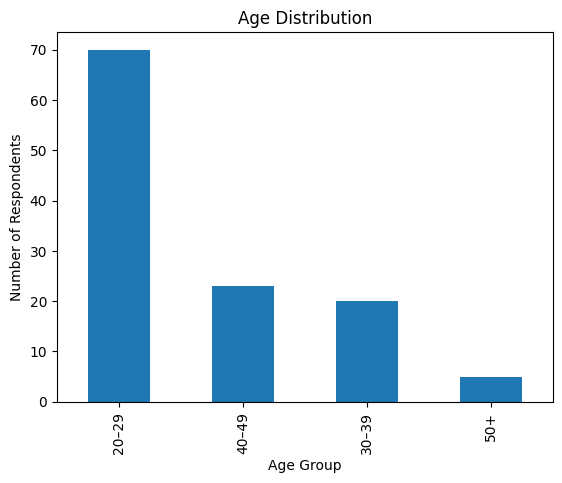

In [ ]:
age_counts = df['Age'].value_counts()
print(age_counts)
age_counts.plot(kind='bar')
plt.title("Age Distribution")
plt.ylabel("Number of Respondents")
plt.xlabel("Age Group")
plt.show()

Gender

Gender
Female    93
Male      25
Name: count, dtype: int64


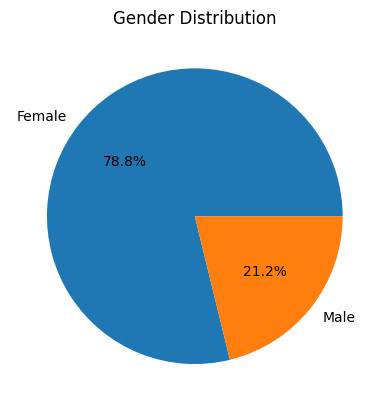

In [ ]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Qualification

Highest Professional Qualification
Bachelor’s Degree             48
Diploma in Midwifery          33
Postgraduate Qualification    20
Others                        17
Name: count, dtype: int64


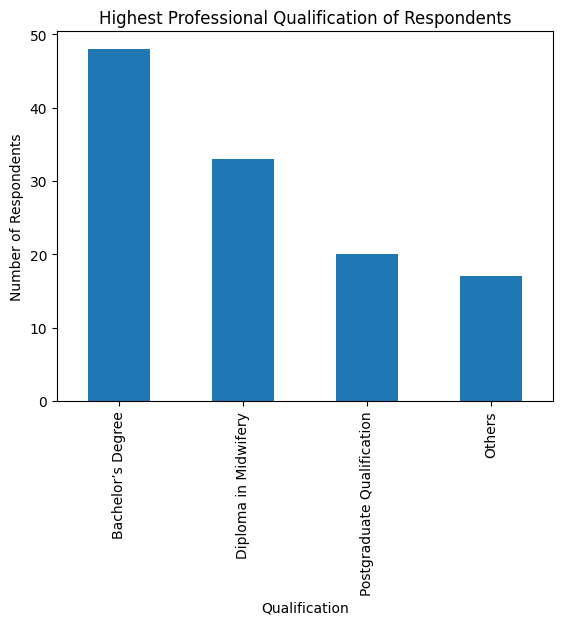

In [ ]:
qualification_counts = df['Highest Professional Qualification'].value_counts()
print(qualification_counts)
qualification_counts.plot(kind='bar')
plt.title("Highest Professional Qualification of Respondents")
plt.xlabel("Qualification")
plt.ylabel("Number of Respondents")
plt.show()

Years of Professional Experience

Years of Professional Experience as a Midwife
Less than 5 years     56
5–10 years            28
11–15 years           24
More than 15 years    10
Name: count, dtype: int64
Years of Professional Experience as a Midwife
Less than 5 years     47.457627
5–10 years            23.728814
11–15 years           20.338983
More than 15 years     8.474576
Name: proportion, dtype: float64


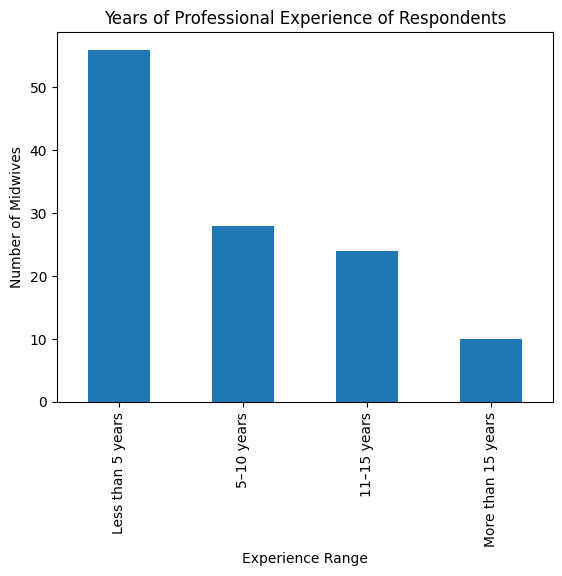

In [ ]:
experience_counts = df['Years of Professional Experience as a Midwife'].value_counts()
print(experience_counts)
experience_percent = df['Years of Professional Experience as a Midwife'].value_counts(normalize=True) * 100
print(experience_percent)
experience_counts.plot(kind='bar')
plt.title("Years of Professional Experience of Respondents")
plt.xlabel("Experience Range")
plt.ylabel("Number of Midwives")
plt.show()

Convert Likert Scale to Numbers

In [ ]:
likert_map = {
    "1 – Strongly Disagree":1,
    "2 – Disagree":2,
    "3 – Neutral":3,
    "4 – Agree":4,
    "5 – Strongly Agree":5
}
df = df.replace(likert_map)

/tmp/ipykernel_2623/1991126936.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(likert_map)


Extract Section B Questions

In [ ]:
section_B = df.filter(like="Section B")
print(section_B.head())

   Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.]  \
0                                                  4                                                                        
1                                                  4                                                                        
2                                                  4                                                                        
3                                                  3                                                                        
4                                                  4                                                                        

   Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).]  \
0                                                  4                                                          

Calculate Mean Score for Each Question

In [ ]:
mean_scores = section_B.mean().sort_values(ascending=False)
print(mean_scores)

Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I promptly refer complicated cases to higher-level facilities.]         4.059322
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I educate mothers on birth preparedness and complication readiness.]    4.059322
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I provide emotional support to mothers during labour.]                  4.042373
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.]                       4.042373
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I monitor maternal vital signs regularly during labour.]                4.025424
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I adhere to infection prevention protocols during delivery.]            4.008475
Section B:  Midwives’ Role in Promoting Safe Delivery Practices [I provide respectful maternity care to all clients.]       

Plot Mean Scores

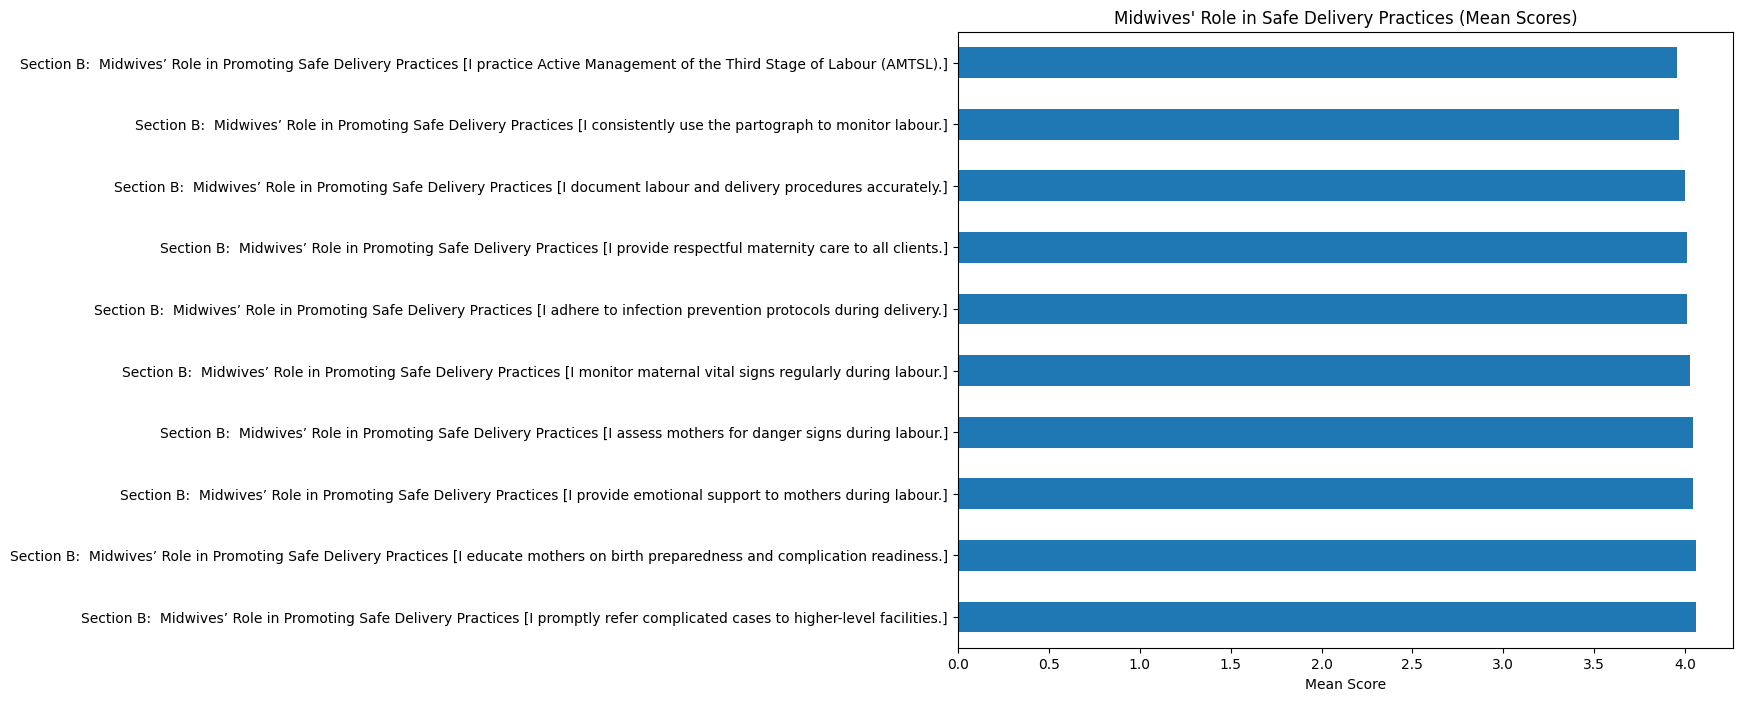

In [ ]:
plt.figure(figsize=(10,8))
mean_scores.plot(kind='barh')
plt.title("Midwives' Role in Safe Delivery Practices (Mean Scores)")
plt.xlabel("Mean Score")
plt.show()

Challenges Analysis

In [ ]:
challenges = df.filter(like="challenges affecting safe delivery")
challenge_mean = challenges.mean().sort_values(ascending=False)
print(challenge_mean)

Please indicate your level of agreement with the following statements regarding challenges affecting safe delivery practices in your facility. [Lack of supportive supervision affects adherence to protocols.]                                        3.677966
Please indicate your level of agreement with the following statements regarding challenges affecting safe delivery practices in your facility. [Inadequate training affects the quality of delivery care.]                                             3.669492
Please indicate your level of agreement with the following statements regarding challenges affecting safe delivery practices in your facility. [Inadequate emergency transportation affects timely referrals.]                                         3.669492
Please indicate your level of agreement with the following statements regarding challenges affecting safe delivery practices in your facility. [Delays in referral systems affect maternal and neonatal outcomes.]                      

Visualization of Challenges

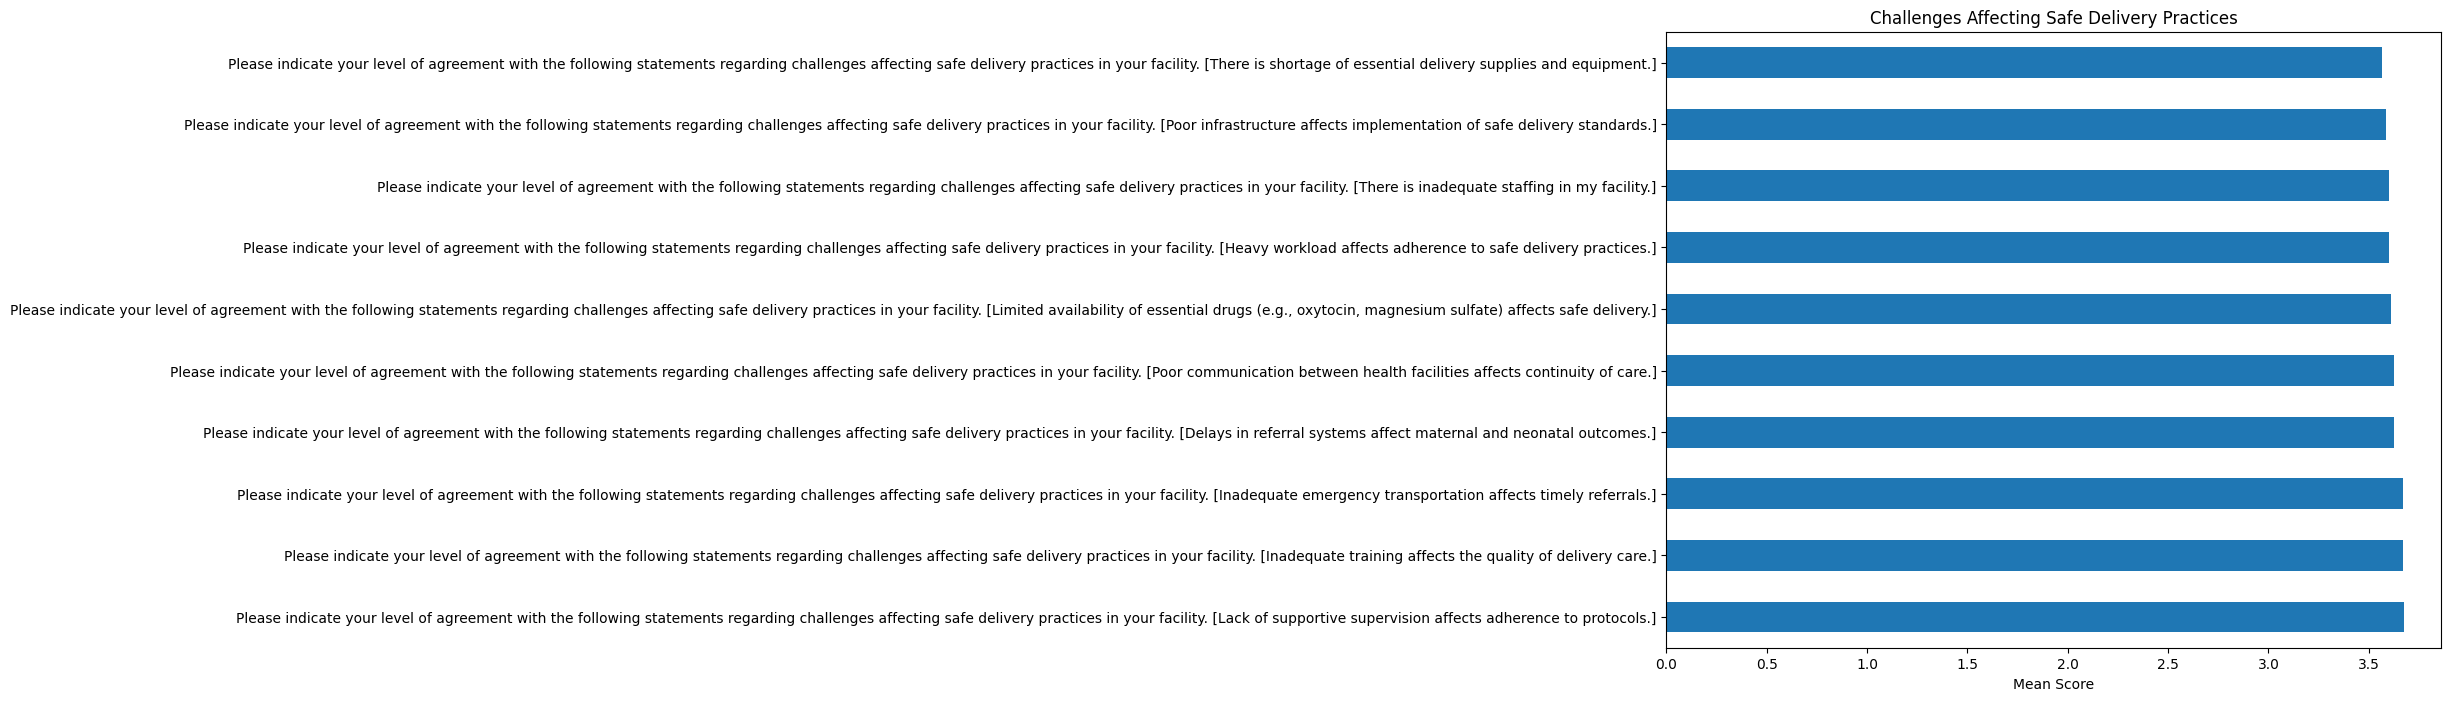

In [ ]:
plt.figure(figsize=(10,8))
challenge_mean.plot(kind='barh')
plt.title("Challenges Affecting Safe Delivery Practices")
plt.xlabel("Mean Score")
plt.show()

Adherence to Safe Delivery Standards

In [ ]:
adherence = df.filter(like="adherence to safe delivery")
adherence_mean = adherence.mean().sort_values(ascending=False)
print(adherence_mean)

Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I adhere to infection prevention and control standards during delivery.]                  4.110169
Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I attend in-service training related to safe delivery practices.]                         4.093220
Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [My professional experience improves my adherence to safe delivery standards.]             4.084746
Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I regularly update my knowledge on maternal and newborn care.]                            4.067797
Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I feel co

Heatmap of All Responses

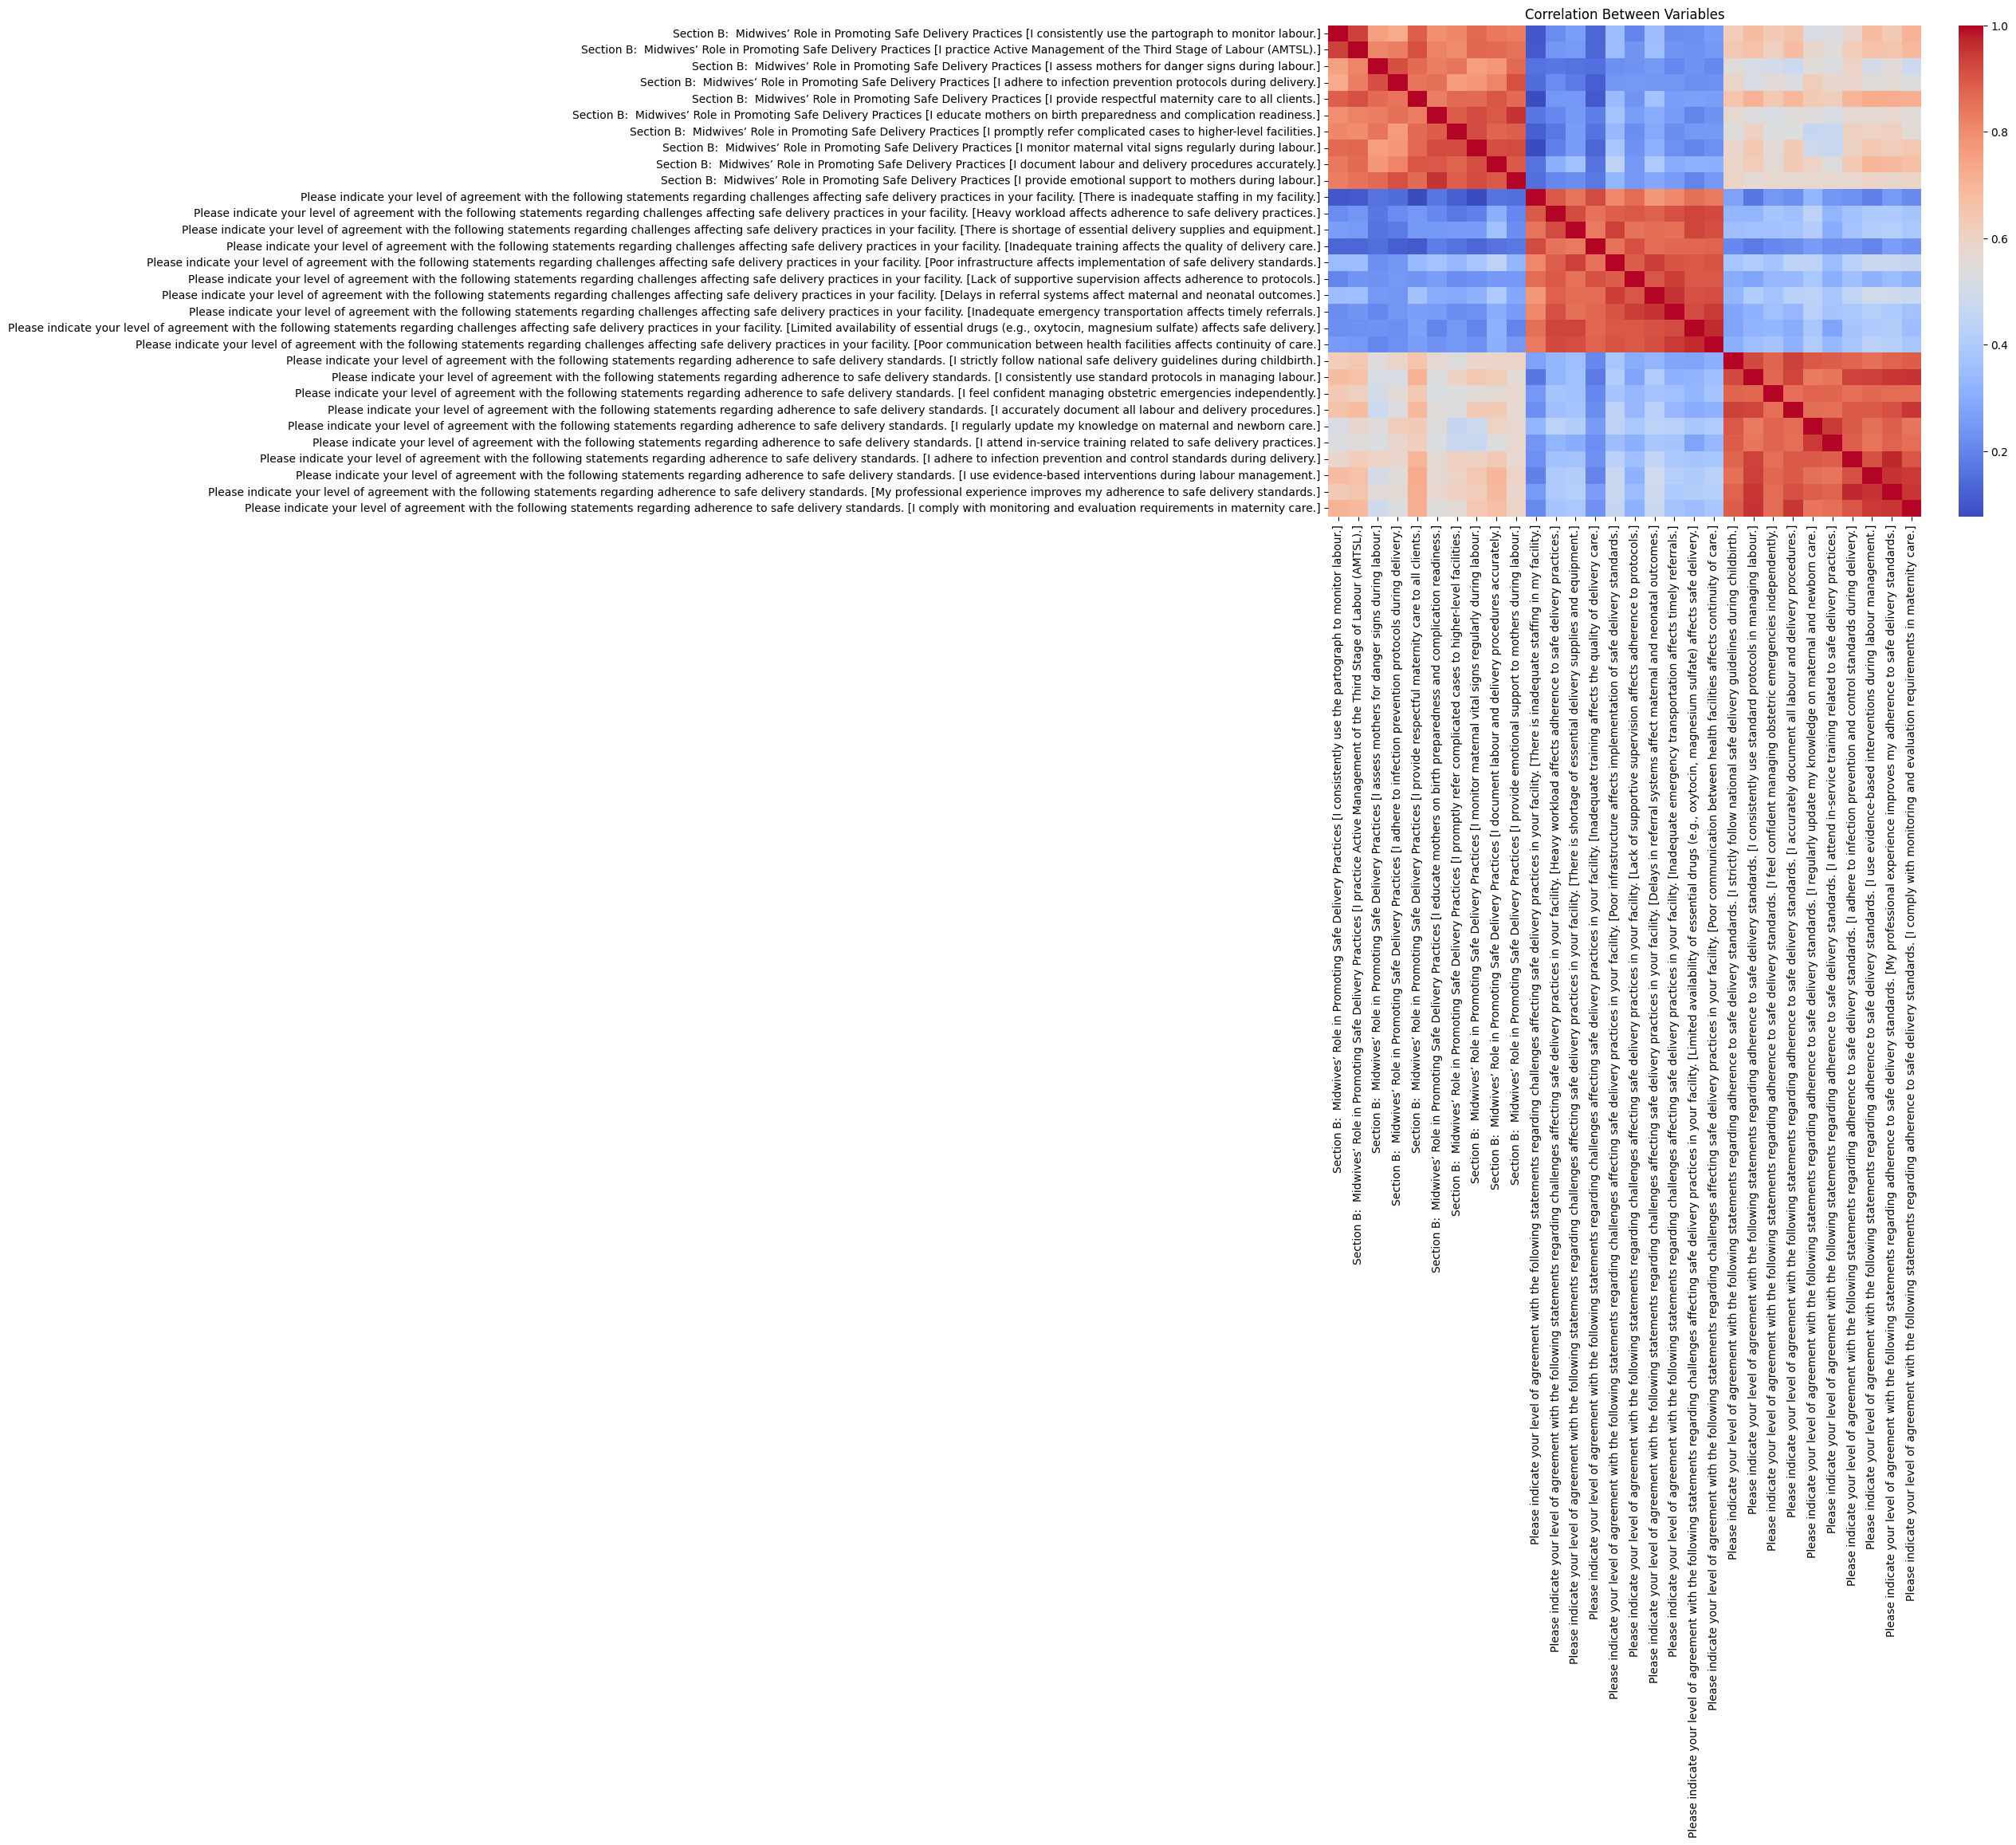

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            cmap="coolwarm",
            annot=False)
plt.title("Correlation Between Variables")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Role Mean Score": mean_scores,
})
results.to_excel("analysis_results.xlsx")

Correlation Between Years of Experience and Adherence

In [ ]:
# Convert Years of Experience to Numeric
experience_map = {
    "Less than 5 years": 2,
    "5–10 years": 7,
    "11–15 years": 13,
    "More than 15 years": 18
}
df["Experience_Num"] = df["Years of Professional Experience as a Midwife"].map(experience_map)


=== CORRELATION RESULTS ===
Pearson Correlation (r): -0.071
P-value: 0.44276
Not statistically significant (p > 0.05)


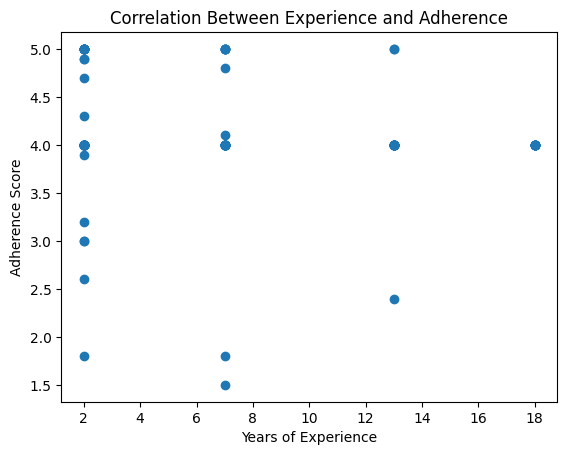

In [ ]:
# Select Adherence Columns (Section D)
adherence_cols = [col for col in df.columns if "adherence to safe delivery standards" in col.lower()]

# Compute Adherence Score
df["Adherence_Score"] = df[adherence_cols].mean(axis=1)

# Correlation Analysis
corr, p_value = pearsonr(df["Experience_Num"], df["Adherence_Score"])
print("Pearson Correlation (r):", round(corr, 3))
print("P-value:", round(p_value, 5))

# Interpretation
if p_value < 0.05:
    print("Statistically significant relationship (p < 0.05)")
else:
    print("Not statistically significant (p > 0.05)")

# Scatter Plot
plt.scatter(df["Experience_Num"], df["Adherence_Score"])
plt.xlabel("Years of Experience")
plt.ylabel("Adherence Score")
plt.title("Correlation Between Experience and Adherence")
plt.show()

Select Numeric Questionnaire Data

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df.head()

,Section B: Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I adhere to infection prevention protocols during delivery.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide respectful maternity care to all clients.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I educate mothers on birth preparedness and complication readiness.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I promptly refer complicated cases to higher-level facilities.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I monitor maternal vital signs regularly during labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I document labour and delivery procedures accurately.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide emotional support to mothers during labour.],...,Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I feel confident managing obstetric emergencies independently.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I accurately document all labour and delivery procedures.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I regularly update my knowledge on maternal and newborn care.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I attend in-service training related to safe delivery practices.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I adhere to infection prevention and control standards during delivery.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I use evidence-based interventions during labour management.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [My professional experience improves my adherence to safe delivery standards.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I comply with monitoring and evaluation requirements in maternity care.],Experience_Num,Adherence_Score
0,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,2,4.0
1,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,7,4.0
2,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,2,4.0
3,3,3,3,3,3,5,5,5,5,4,...,3,3,3,3,4,4,4,3,2,3.2
4,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,2,4.0


In [ ]:
desc_stats = numeric_df.describe()
desc_stats

,Section B: Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I adhere to infection prevention protocols during delivery.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide respectful maternity care to all clients.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I educate mothers on birth preparedness and complication readiness.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I promptly refer complicated cases to higher-level facilities.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I monitor maternal vital signs regularly during labour.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I document labour and delivery procedures accurately.],Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide emotional support to mothers during labour.],...,Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I feel confident managing obstetric emergencies independently.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I accurately document all labour and delivery procedures.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I regularly update my knowledge on maternal and newborn care.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I attend in-service training related to safe delivery practices.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I adhere to infection prevention and control standards during delivery.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I use evidence-based interventions during labour management.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [My professional experience improves my adherence to safe delivery standards.],Please indicate your level of agreement with the following statements regarding adherence to safe delivery standards. [I comply with monitoring and evaluation requirements in maternity care.],Experience_Num,Adherence_Score
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,...,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000
mean,3.966102,3.957627,4.042373,4.008475,4.008475,4.059322,4.059322,4.025424,4.000000,4.042373,...,4.067797,4.050847,4.067797,4.093220,4.110169,4.059322,4.084746,4.059322,6.779661,4.066949
std,0.703255,0.684306,0.632375,0.633748,0.685575,0.630999,0.617306,0.659731,0.679366,0.604740,...,0.580728,0.611114,0.609453,0.626853,0.551360,0.683035,0.621224,0.657532,5.444570,0.602141
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.500000
25%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,7.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4

Cronbach’s Alpha (Reliability)

In [ ]:
def cronbach_alpha(data):
    data = data.dropna()
    item_variances = data.var(axis=0, ddof=1)
    total_score = data.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    k = data.shape[1]
    alpha = (k/(k-1))*(1 - item_variances.sum()/total_variance)
    return alpha
alpha = cronbach_alpha(numeric_df)
print("Cronbach Alpha:", alpha)

Cronbach Alpha: 0.8832832855674932


Factor Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


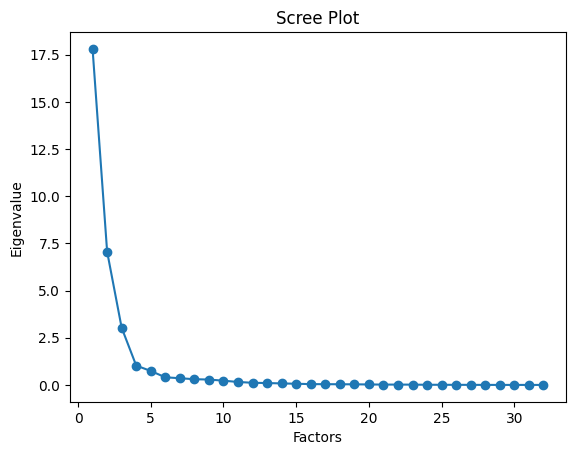

In [ ]:
fa = FactorAnalyzer()
fa.fit(numeric_df)
ev, v = fa.get_eigenvalues()
plt.scatter(range(1,len(ev)+1), ev)
plt.plot(range(1,len(ev)+1), ev)
plt.title("Scree Plot")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.show()

Extract Factor Loadings

In [ ]:
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(numeric_df)
loadings = pd.DataFrame(
    fa.loadings_,
    index=numeric_df.columns
)
loadings

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,0,1,2
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I consistently use the partograph to monitor labour.],0.399552,0.080451,0.797933
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I practice Active Management of the Third Stage of Labour (AMTSL).],0.397180,0.085723,0.831179
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I assess mothers for danger signs during labour.],0.266089,0.066951,0.844122
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I adhere to infection prevention protocols during delivery.],0.309239,0.071023,0.829644
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide respectful maternity care to all clients.],0.448757,0.079365,0.836061
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I educate mothers on birth preparedness and complication readiness.],0.261819,0.108147,0.900420
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I promptly refer complicated cases to higher-level facilities.],0.280015,0.089917,0.876730
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I monitor maternal vital signs regularly during labour.],0.321141,0.076674,0.885888
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I document labour and delivery procedures accurately.],0.361759,0.155550,0.854517
Section B: Midwives’ Role in Promoting Safe Delivery Practices [I provide emotional support to mothers during labour.],0.293511,0.087843,0.916172


Regression Analysis

In [ ]:
X = numeric_df.iloc[:, :-1]
y = numeric_df.iloc[:, -1]
model = LinearRegression()
model.fit(X, y)
coefficients = pd.DataFrame({
    "Variable":X.columns,
    "Coefficient":model.coef_
})
coefficients

,Variable,Coefficient
0,Section B: Midwives’ Role in Promoting Safe D...,-4.529893e-14
1,Section B: Midwives’ Role in Promoting Safe D...,3.680389e-14
2,Section B: Midwives’ Role in Promoting Safe D...,3.511861e-14
3,Section B: Midwives’ Role in Promoting Safe D...,-3.848109e-14
4,Section B: Midwives’ Role in Promoting Safe D...,-1.944552e-14
5,Section B: Midwives’ Role in Promoting Safe D...,4.886550e-14
6,Section B: Midwives’ Role in Promoting Safe D...,-1.537478e-14
7,Section B: Midwives’ Role in Promoting Safe D...,-1.241592e-14
8,Section B: Midwives’ Role in Promoting Safe D...,2.626505e-14
9,Section B: Midwives’ Role in Promoting Safe D...,-1.827379e-14
